In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Load your Credit Card Fraud dataset
data_path = r"D:\Projects\all_fraud_detection\notebook\credit_combined_dataset.csv"
data = pd.read_csv(data_path)
data.head()

,sequence_no,transaction_id,card_number,card_holder_name,merchant_category,transaction_amount,transaction_date,transaction_time,transaction_type,location,channel,previous_fraud_count,is_international,label
0,1,TXN1001,XXXX-XXXX-XXXX-7311,Norma Fisher,Travel,298.37,2025-06-03,19:14:57,ATM Withdrawal,Hyderabad,Mobile App,3,1,not fraud
1,2,TXN1002,XXXX-XXXX-XXXX-4578,Dr. Ronald Faulkner,Grocery,1481.01,2025-06-12,00:56:31,Online,Pune,POS Terminal,1,1,fraud
2,3,TXN1003,XXXX-XXXX-XXXX-2208,Colleen Taylor,Pharmacy,1717.97,2025-05-22,14:46:20,ATM Withdrawal,Mumbai,Mobile App,2,0,not fraud
3,4,TXN1004,XXXX-XXXX-XXXX-8815,Robert Archer,Fuel,1376.41,2025-06-29,03:37:52,ATM Withdrawal,Mumbai,POS Terminal,3,0,not fraud
4,5,TXN1005,XXXX-XXXX-XXXX-6458,Stephanie Collins,Pharmacy,1693.50,2025-05-16,12:18:29,Online,Delhi,Web,1,0,not fraud


In [20]:
# Clean column names: strip spaces and convert to lowercase
data.columns = data.columns.str.strip().str.lower()

# Drop identifier columns
drop_cols = ['sequence_no', 'transaction_id', 'card_number', 'card_holder_name', 'transaction_date', 'transaction_time']
# Only drop columns that exist in the dataset
drop_cols = [col for col in drop_cols if col in data.columns]
data = data.drop(columns=drop_cols)

# Encode categorical features
categorical_cols = ['merchant_category', 'transaction_type', 'location', 'channel']
for col in categorical_cols:
    if col in data.columns:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

# Encode target column: 'fraud'->1, 'not fraud'->0
data['label'] = data['label'].map({'not fraud':0, 'fraud':1})

# Split features and target
X = data.drop('label', axis=1)
y = data['label']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16
Testing samples: 4


In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [22]:
# XGBoost without use_label_encoder
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [23]:
# LightGBM with smaller leaf and bin parameters
lgb_model = lgb.LGBMClassifier(min_data_in_leaf=1, min_data_in_bin=1, random_state=42)
lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Number of positive: 2, number of negative: 14
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.125000 -> initscore=-1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [24]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    return acc, f1, precision, recall

--- Random Forest ---
Accuracy: 0.75
F1 Score: 0.0
Precision: 0.0
Recall: 0.0


c:\Users\Sayal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


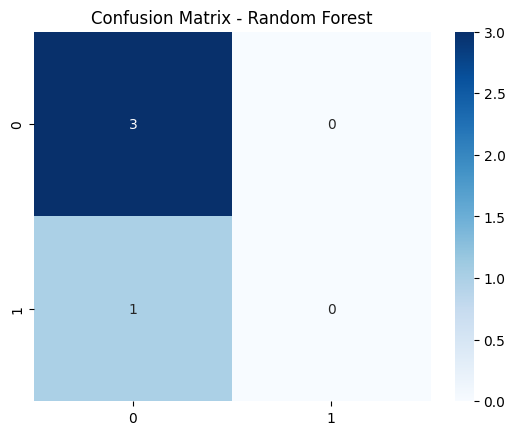

NameError: name 'y_pred_xgb' is not defined

In [25]:
results = {}
results['Random Forest'] = evaluate_model(y_test, y_pred_rf, 'Random Forest')
results['XGBoost'] = evaluate_model(y_test, y_pred_xgb, 'XGBoost')
results['LightGBM'] = evaluate_model(y_test, y_pred_lgb, 'LightGBM')

In [ ]:
results_df = pd.DataFrame(results, index=['Accuracy', 'F1 Score', 'Precision', 'Recall']).T
print("Comparison Table:\n")
print(results_df)

best_model = results_df['Accuracy'].idxmax()
print(f"\nBest Model based on Accuracy: {best_model}")

Comparison Table:

               Accuracy  F1 Score  Precision  Recall
Random Forest      0.75       0.0        0.0     0.0
XGBoost            0.75       0.0        0.0     0.0
LightGBM           0.75       0.0        0.0     0.0

Best Model based on Accuracy: Random Forest


In [ ]:
import joblib

# Save Random Forest
joblib.dump(rf_model, r"D:\Projects\all_fraud_detection\notebook\rf_model.pkl")

# Save XGBoost
joblib.dump(xgb_model, r"D:\Projects\all_fraud_detection\notebook\xgb_model.pkl")

# Save LightGBM
joblib.dump(lgb_model, r"D:\Projects\all_fraud_detection\notebook\lgb_model.pkl")

print("All models saved successfully!")

All models saved successfully!


In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
data = pd.read_csv(r"D:\Projects\all_fraud_detection\notebook\credit_combined_dataset.csv")

# Clean columns
data.columns = data.columns.str.strip().str.lower()

# Drop identifiers
drop_cols = ['sequence_no','transaction_id','card_number','card_holder_name','transaction_date','transaction_time']
data = data.drop(columns=[c for c in drop_cols if c in data.columns])

# Encode categoricals
categorical_cols = ['merchant_category','transaction_type','location','channel']
for col in categorical_cols:
    if col in data.columns:
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# Encode target
data['label'] = data['label'].map({'not fraud':0, 'fraud':1})

X = data.drop('label', axis=1)
y = data['label']

print("Class Distribution:\n", y.value_counts())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessing
numeric_features = X.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)]
)

# Pipeline with balanced RF
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Save
joblib.dump(model, r"D:\Projects\all_fraud_detection\models\credit_model.pkl")

print("✅ Credit Card Model Saved Successfully")

Class Distribution:
 label
0    17
1     3
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4

✅ Credit Card Model Saved Successfully


c:\Users\Sayal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sayal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sayal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Dataset Shape: (60, 14)
Training samples: 48
Testing samples: 12
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Number of positive: 15, number of negative: 33
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 72
[LightGBM] [Info] Number of data points in the train set: 48, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.312500 -> initscore=-0.788457
[LightGBM] [Info] Start training from score -0.788457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

c:\Users\Sayal\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [13:25:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


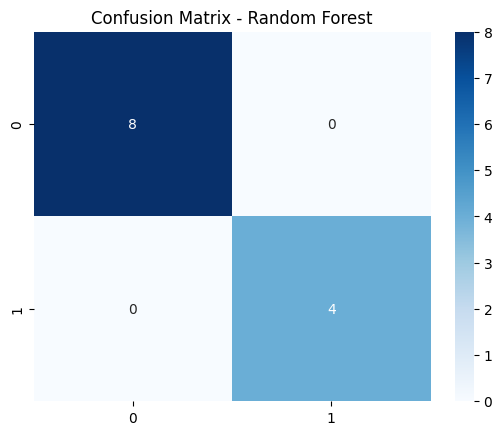


--- XGBoost ---
Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0
Recall: 1.0


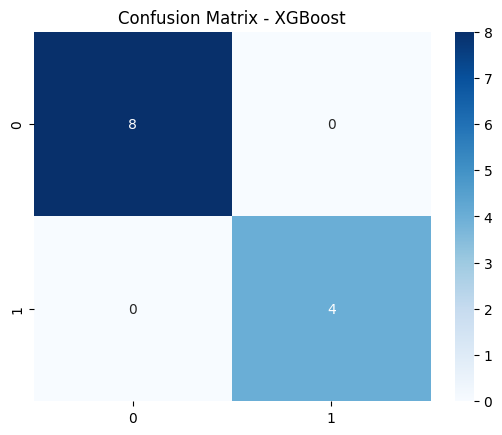


--- LightGBM ---
Accuracy: 0.9166666666666666
F1 Score: 0.8888888888888888
Precision: 0.8
Recall: 1.0


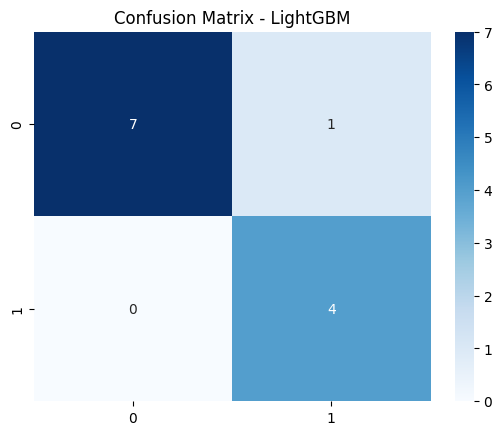


Model Comparison Table
               Accuracy  F1 Score  Precision  Recall
Random Forest  1.000000  1.000000        1.0     1.0
XGBoost        1.000000  1.000000        1.0     1.0
LightGBM       0.916667  0.888889        0.8     1.0

Best Model: Random Forest

All models saved successfully

Running SHAP Explainability...


c:\Users\Sayal\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


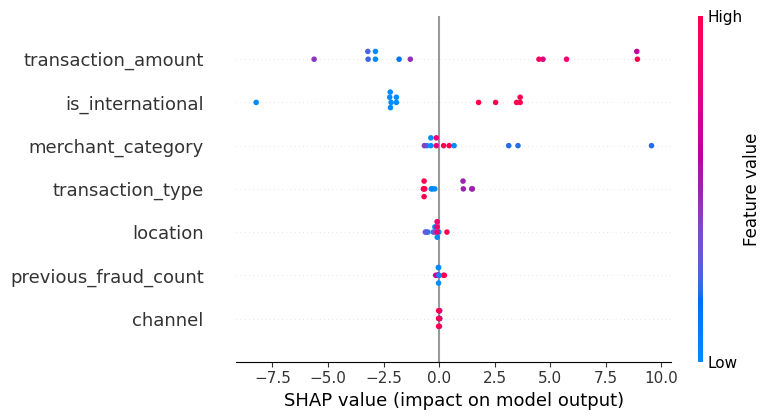

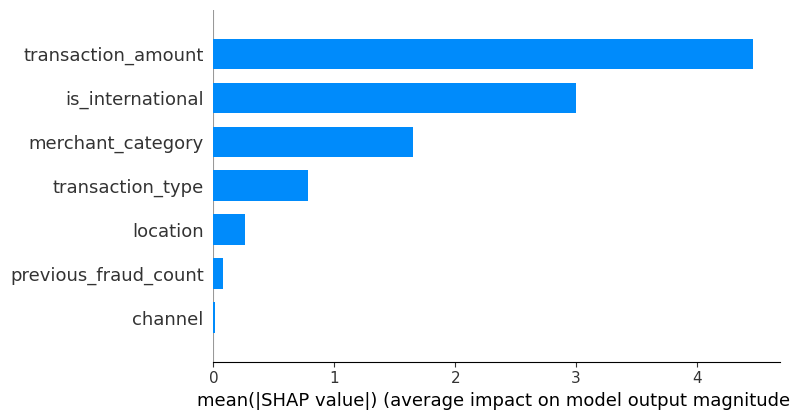


Top 5 Features Influencing Fraud Detection
              Feature  Importance
1  transaction_amount    4.463351
6    is_international    2.995376
0   merchant_category    1.647407
2    transaction_type    0.781681
3            location    0.257070

Top 3 Reasons for Prediction
              Feature   Value  SHAP Impact               Impact
1  transaction_amount  420.77    -2.866596  Decrease Fraud Risk
6    is_international    0.00    -1.925454  Decrease Fraud Risk
2    transaction_type    2.00    -0.678642  Decrease Fraud Risk


In [27]:
# ===============================
# Import Libraries
# ===============================
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb


# ===============================
# Load Dataset
# ===============================
data_path = r"D:\Projects\all_fraud_detection\notebook\credit_combined_dataset.csv"
data = pd.read_csv(data_path)

print("Dataset Shape:", data.shape)
data.head()


# ===============================
# Data Cleaning
# ===============================
data.columns = data.columns.str.strip().str.lower()

drop_cols = [
    'sequence_no','transaction_id','card_number',
    'card_holder_name','transaction_date','transaction_time'
]

drop_cols = [c for c in drop_cols if c in data.columns]
data = data.drop(columns=drop_cols)


# ===============================
# Encode Categorical Columns
# ===============================
categorical_cols = ['merchant_category','transaction_type','location','channel']

for col in categorical_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))


# ===============================
# Encode Target Column
# ===============================
data['label'] = data['label'].map({'not fraud':0,'fraud':1})

X = data.drop('label',axis=1)
y = data['label']


# ===============================
# Train Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])


# ===============================
# Train Models
# ===============================

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)


# XGBoost (fixed version)
xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(X_train,y_train)
y_pred_xgb = xgb_model.predict(X_test)


# LightGBM
lgb_model = lgb.LGBMClassifier(
    min_data_in_leaf=1,
    min_data_in_bin=1,
    random_state=42
)

lgb_model.fit(X_train,y_train)
y_pred_lgb = lgb_model.predict(X_test)


# ===============================
# Evaluation Function
# ===============================
def evaluate_model(y_true,y_pred,model_name):

    acc = accuracy_score(y_true,y_pred)
    f1 = f1_score(y_true,y_pred)
    precision = precision_score(y_true,y_pred)
    recall = recall_score(y_true,y_pred)

    print(f"\n--- {model_name} ---")
    print("Accuracy:",acc)
    print("F1 Score:",f1)
    print("Precision:",precision)
    print("Recall:",recall)

    cm = confusion_matrix(y_true,y_pred)

    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return acc,f1,precision,recall


# ===============================
# Compare Models
# ===============================
results = {}

results['Random Forest'] = evaluate_model(y_test,y_pred_rf,'Random Forest')
results['XGBoost'] = evaluate_model(y_test,y_pred_xgb,'XGBoost')
results['LightGBM'] = evaluate_model(y_test,y_pred_lgb,'LightGBM')


results_df = pd.DataFrame(
    results,
    index=['Accuracy','F1 Score','Precision','Recall']
).T

print("\nModel Comparison Table")
print(results_df)


best_model = results_df['Accuracy'].idxmax()
print("\nBest Model:",best_model)


# ===============================
# Save Models
# ===============================
joblib.dump(rf_model,r"D:\Projects\all_fraud_detection\notebook\rf_model.pkl")
joblib.dump(xgb_model,r"D:\Projects\all_fraud_detection\notebook\xgb_model.pkl")
joblib.dump(lgb_model,r"D:\Projects\all_fraud_detection\notebook\lgb_model.pkl")

print("\nAll models saved successfully")


# ===============================
# SHAP Explainable AI
# ===============================

print("\nRunning SHAP Explainability...")

explainer = shap.TreeExplainer(lgb_model)

shap_values = explainer.shap_values(X_test)


# SHAP Summary Plot
shap.summary_plot(shap_values,X_test)


# SHAP Feature Importance
shap.summary_plot(shap_values,X_test,plot_type="bar")


# ===============================
# Top 5 Important Features
# ===============================

importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature":X_test.columns,
    "Importance":importance
})

top5 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(5)

print("\nTop 5 Features Influencing Fraud Detection")
print(top5)


# ===============================
# Explain One Transaction
# ===============================

index = 0

transaction = X_test.iloc[index]

shap_val = shap_values[index]

explanation = pd.DataFrame({
    "Feature":X_test.columns,
    "Value":transaction.values,
    "SHAP Impact":shap_val
})

explanation["Impact"] = explanation["SHAP Impact"].apply(
    lambda x: "Increase Fraud Risk" if x>0 else "Decrease Fraud Risk"
)

top3 = explanation.reindex(
    explanation["SHAP Impact"].abs().sort_values(ascending=False).index
).head(3)

print("\nTop 3 Reasons for Prediction")
print(top3)